# Explore l'embedding à travers différentes architecture

J'ouvre un notebook à part pour ce topic en marge
Faire tourné des models pour l'éfficacité sur différent device
quand on fait des tests dans un coin on peut se permettre de faire chauffer sa CPU
mais que ce passe t-il pour addres les GPU / NPU / XPU / QPU  cuda  amd intel ...

petit détour dans le monde matériel (le device backend)



## les imports

In [2]:
## les imports
#les imports centralisés et options
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

import bs4
from wordcloud import WordCloud 
import urllib.request
import spacy
import time
import os
import sys
import subprocess
import platform

from sentence_transformers import SentenceTransformer
import importlib

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)



## Diagnostique de device - que peut on faire avec notre backend (CPU ? GPU ? NPU ?)

Par exemple, voici les prereqs pour faire du GPU Intel Arc
La première chose est de vérifier la version de torch et sa dépendance à l'architecture


Vérifier par un moyen qu'un driver existe, est installé et à une version supérieur à 31.0
Get-WmiObject Win32_VideoController | Select-Object Name, DriverVersion

Name                             DriverVersion
----                             -------------
Intel(R) Arc(TM) 140V GPU (16GB) 32.0.101.8132

ensuite, il faudrait installer le torch correspondant

uv tree

càd désinstaller le torch existant, qui est venu de l'install de sentence-transformer v5.3
et réinstaller un autre torch

# Désinstaller l'actuel avec uv
uv remove torch torchvision torchaudio

# Réinstaller le build XPU
uv add torch torchvision torchaudio --index-url https://download.pytorch.org/whl/xpu

Bon c'est un peu la battle, mais on est là pour explorer essayer et casser les choses, alors alons y :


uv pip uninstall torch torchvision torchaudio

Mise à jour du project.toml


Puis uv sync --active
one liner de test
python -c "import torch ; torch.xpu.is_available()"

## les data de commenter pour l'embedding

In [4]:
df40_phrases = pd.read_csv(Path("data/df40_phrases.csv"),sep=";")
df40_comments = pd.read_csv(Path("data/df40_comments.csv"),sep=";")
display(df40_phrases.shape ,df40_comments.shape
 , df40_phrases.head(10) )

(80521, 3)

(39924, 17)

,idCommentaire,idPhrase,Phrase
0,1,1,Produit conforme.
1,1,2,"La description du contenue est ambiguë car il faut 2 joints , sur la description il y a indiqué 2 mais en final reçu 1"
2,2,1,NaN
3,3,1,..............R.A.S.........
4,4,1,NaN
5,5,1,Tres bien mais attention bien scotcher les colis.
6,5,2,Dernièrement j’ai reçu l’un d’eux ouvert !!
7,5,3,Merci.
8,6,1,Piece conforme mais la gaine de protection sur la durite était abîmée( sans concéquence sur le bon fonctionnement)
9,7,1,Very good


## Exploration CPU GPU NPU XPU CUDA MPS ROCm
problématique, en fonction de sa machine et des disponibilités, s'offrir un framework simple de choix de backend hardware et de transformer

Architectures 
| Architecture | Plateforme | Détection |
|--------------|------------|-----------|
| MPS (Metal Performance Shaders) | Mac Apple Silicon (M1/M2/M3) | torch.backends.mps.is_available() | 
| ROCm | Linux + GPU AMD | torch.version.hip is not None | 
| XPU | Linux + GPU Intel Arc | torch.xpu.is_available() | 
| CUDA | Linux/Windows + GPU NVIDIA | torch.cuda.is_available() |

| Architecture | Plateforme |
| CUDA | NVIDIA | 
| Windows/LinuxMPSApple Silicon — MacROCmAMD — LinuxXPUIntel Arc — Windows/LinuxNPUIntel Neural EngineCPUFallback universel


In [48]:
from openvino import Core
from optimum.intel import sentenceTransformer #as SentenceTransformer

def detect_device() -> str:
    try:
        core = Core()
        devices = core.available_devices
        if "NPU" in devices:
            return "NPU"
        if "GPU" in devices:
            return "GPU"
        return "CPU"
    except Exception:
        return "CPU"

# doc error
#  Expected one of cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, maia, xla, lazy, vulkan, mps, meta, hpu, mtia, privateuseone device type at start of device string: NPU

def load_sentence_transformer(model_name: str, force_device: str = "auto") -> tuple:
    device = force_device.lower() if force_device != "auto" else detect_device()
    print(f"✓ Detected device : {device}")
    model = SentenceTransformer(model_name, device=device) #, export=True
    print(f"✓ OpenVINO — device : {device}")
    return model, device



model, device = load_sentence_transformer("sentence-transformers/all-MiniLM-L6-v2", force_device="npu")

ImportError: cannot import name 'sentenceTransformer' from 'optimum.intel' (c:\Users\lione\Documents\GitHub\Supply-Chain-Reviews\.venv313\Lib\site-packages\optimum\intel\__init__.py)

In [17]:
sentences = ["This is an example sentence", "Each sentence is converted"]
embeddings = model.encode(sentences)
embeddings

array([[ 6.76569194e-02,  6.34959489e-02,  4.87130620e-02,
         7.93049559e-02,  3.74480821e-02,  2.65276735e-03,
         3.93749215e-02, -7.09845126e-03,  5.93614355e-02,
         3.15369777e-02,  6.00980893e-02, -5.29051349e-02,
         4.06068079e-02, -2.59308126e-02,  2.98428535e-02,
         1.12689473e-03,  7.35148266e-02, -5.03818728e-02,
        -1.22386612e-01,  2.37028226e-02,  2.97265332e-02,
         4.24768627e-02,  2.56337412e-02,  1.99514697e-03,
        -5.69190308e-02, -2.71598231e-02, -3.29035670e-02,
         6.60248697e-02,  1.19007193e-01, -4.58791293e-02,
        -7.26214647e-02, -3.25840227e-02,  5.23413084e-02,
         4.50553000e-02,  8.25297460e-03,  3.67023945e-02,
        -1.39415506e-02,  6.53918907e-02, -2.64272243e-02,
         2.06403842e-04, -1.36643536e-02, -3.62809971e-02,
        -1.95044018e-02, -2.89737936e-02,  3.94270532e-02,
        -8.84090737e-02,  2.62421533e-03,  1.36713730e-02,
         4.83062342e-02, -3.11566330e-02, -1.17329150e-0

In [3]:
detect_device()

NameError: name 'detect_device' is not defined

In [4]:
#Si Le backend OpenVINO n'est pas correctement lié à sentence-transformers. Vérifiez ce qui est installé :
# import pkg_resources deprecated
from importlib.metadata import version, PackageNotFoundError

for pkg in ["optimum", "optimum-intel", "openvino", "sentence-transformers"]:
    try:
        print(f"✓ {pkg} : {version(pkg)}")
    except PackageNotFoundError:
        print(f"✗ {pkg} : NON INSTALLÉ")


✓ optimum : 2.1.0
✓ optimum-intel : 1.27.0
✓ openvino : 2026.0.0
✓ sentence-transformers : 5.3.0


In [17]:
print(r"data\PM-MiniLM-L12-v2-fp16\openvino_model.xml")
print(str(Path("data") / "PM-MiniLM-L12-v2-fp16" / "openvino_model.xml"))

data\PM-MiniLM-L12-v2-fp16\openvino_model.xml
data\PM-MiniLM-L12-v2-fp16\openvino_model.xml


In [34]:
#import importlib
#importlib.reload(sys.modules["sentence_transformers"])
from sentence_transformers import SentenceTransformer
print(Path("data/PM-MiniLM-L12-v2-fp16/openvino_model.xml"))
print(Path("data") / "PM-MiniLM-L12-v2-fp16")

MODEL_PATH = Path("data") / "PM-MiniLM-L12-v2-fp16"
MODEL_PATH = Path("data/PM-MiniLM-L12-v2-fp16/openvino_model.xml")
model = SentenceTransformer(r"data\PM-MiniLM-L12-v2-fp16"
, model_kwargs={"local_files_only": True}
, tokenizer_kwargs={"local_files_only": True}
, backend="openvino"
, device="GPU"
)
                                    
sentences = ["This is an example sentence", "Each sentence is converted"]
embeddings = model.encode(sentences)

No sentence-transformers model found with name data\PM-MiniLM-L12-v2-fp16. Creating a new one with mean pooling.
Could not infer whether the model was already converted or not to the OpenVINO IR, keeping `export=False`.
[Errno 2] No such file or directory: 'C:\\Users\\lione\\.cache\\huggingface\\hub\\models--data\\PM-MiniLM-L12-v2-fp16\\refs\\main'


data\PM-MiniLM-L12-v2-fp16\openvino_model.xml
data\PM-MiniLM-L12-v2-fp16


ValueError: This model is a Sentence Transformers model. Please use `OVSentenceTransformer` to load this model.

In [35]:
from optimum.intel import OVSentenceTransformer

model = OVSentenceTransformer(
    "data/PM-MiniLM-L12-v2-fp16",
    device="GPU",
)

AttributeError: 'str' object has no attribute 'inputs'

In [1]:
#A EVITER TROP GROS POUR JUSTE DU transformers
from huggingface_hub import snapshot_download
if False:
    snapshot_download(
        repo_id="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        local_dir="data/PM-MiniLM-L12-v2-fp16-complet",
    )

## Enfin qq chose qui est opérationelle et intéressant
le chargement spécifique machine de certaine ressources finement choise de hugging face


In [4]:
#Téléchargement manuel des fichiers essentiels pour SentenceTransformer
from huggingface_hub import hf_hub_download
import os

repo_id = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
local_dir = "data/PM-MiniLM-L12-v2-complet"

# Uniquement les fichiers requis par SentenceTransformer
fichiers = [
    "modules.json",
    "sentence_bert_config.json",
    "config.json",
    "tokenizer.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
    "1_Pooling/config.json", 
    "openvino/openvino_model.xml",
    "openvino/openvino_model.bin",
]

os.makedirs(local_dir, exist_ok=True)
os.makedirs(local_dir + "/openvino", exist_ok=True)
os.makedirs(local_dir + "/1_Pooling", exist_ok=True)

for fichier in fichiers:
    hf_hub_download(
        repo_id=repo_id,
        filename=fichier,
        local_dir=local_dir,
    )
    print(f"✓ {fichier}")

✓ modules.json
✓ sentence_bert_config.json
✓ config.json
✓ tokenizer.json
✓ tokenizer_config.json
✓ special_tokens_map.json
✓ 1_Pooling/config.json


openvino_model.xml: 0.00B [00:00, ?B/s]

✓ openvino/openvino_model.xml


openvino/openvino_model.bin:   0%|          | 0.00/470M [00:00<?, ?B/s]

✓ openvino/openvino_model.bin


In [ ]:
def listSubModule(M,level=0,excepts=["np","warnings","time","logger","numbers","sp"], levelMAx=3):
    level+=1
    print()
    print("  "*level, level, "MODULE :: ",M.__name__ , M.__path__ )#, M)
    for i in dir(M):
        submodule=getattr(M, i)
        if type(submodule).__name__ == "module":
            print("  "*level, level,type(submodule).__name__ , i )
            if level < levelMAx and i not in excepts:
                level=listSubModule(submodule,level=level, levelMAx=levelMAx)
        if type(submodule).__name__ == "function":
            print("  "*level, level, type(submodule).__name__ , f":: from {M.__name__} import {i}")
    print("")        
    return level-1

import sentence_transformers
listSubModule(sentence_transformers, levelMAx=2)



   1 MODULE ::  sentence_transformers ['c:\\Users\\lione\\Documents\\GitHub\\Supply-Chain-Reviews\\.venv313\\Lib\\site-packages\\sentence_transformers']
   1 module backend

     2 MODULE ::  sentence_transformers.backend ['c:\\Users\\lione\\Documents\\GitHub\\Supply-Chain-Reviews\\.venv313\\Lib\\site-packages\\sentence_transformers\\backend']
     2 function :: from sentence_transformers.backend import _save_pretrained_wrapper
     2 function :: from sentence_transformers.backend import backend_should_export
     2 function :: from sentence_transformers.backend import backend_warn_to_save
     2 function :: from sentence_transformers.backend import export_dynamic_quantized_onnx_model
     2 function :: from sentence_transformers.backend import export_optimized_onnx_model
     2 function :: from sentence_transformers.backend import export_static_quantized_openvino_model
     2 module load
     2 function :: from sentence_transformers.backend import load_onnx_model
     2 function :: f

AttributeError: module 'sentence_transformers.data_collator' has no attribute '__path__'

In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "data/PM-MiniLM-L12-v2-complet",
    backend="openvino",
    device="xpu"
)

In [18]:
import openvino as ov
#from optimum.intel import OVSentenceTransformer
#from transformers import AutoTokenizer

# 1. Charger le modèle au niveau OpenVINO (L'objet ModelBase/Node)
core = ov.Core()
ov_model = core.read_model(model="./data/PM-MiniLM-L12-v2-complet/openvino/openvino_model.xml")
print(core.get_available_devices())
# On définit des dimensions STATIQUES (Batch size = 1, Sequence length = 128)
# Cela évite l'erreur "Upper bounds not specified"

ov_model.reshape({
    "input_ids": [2, 128],
    "attention_mask": [2, 128]
    #,"token_type_ids": [1, 128]
})

# 2. Instancier OVSentenceTransformer via le dossier (pour les configs JSON)
# MAIS on utilise une astuce pour éviter qu'il ne cherche à compiler tout de suite
#model = OVSentenceTransformer.from_pretrained(ov_model,export=False,  device="NPU")

# 3. L'INJECTION CHIRURGICALE
# On remplace l'objet modèle interne par celui que vous avez chargé manuellement
# Cela garantit que c'est bien votre 'openvino._pyopenvino.Model' qui est utilisé
model.model = ov_model 

# 4. Compilation manuelle pour le NPU
# Dans la hiérarchie OpenVINO, un Model doit être "compilé" pour un device
model.request = core.compile_model(model.model, device_name="NPU")
print(dir(model))
print(f"Injection réussie. Le modèle tourne sur : {model.model.friendly_name} avec backend {model._target_device}")

['CPU', 'GPU', 'NPU']


: 

In [4]:
dir(ov_model)


NameError: name 'ov_model' is not defined

In [13]:
sentences = ["This is an example sentence", "Each sentence is converted"]
embeddings = model.encode(sentences)
embeddings

array([[ 0.18845682,  0.17425619,  0.05447771,  0.29051754,  0.1676641 ,
        -0.04720684,  0.6455802 ,  0.15980883,  0.22689246, -0.03089056,
         0.25588354, -0.05258782, -0.22610116, -0.05710642,  0.1304262 ,
         0.12495339,  0.31749612,  0.19444387, -0.58632535, -0.01258612,
         0.6099091 ,  0.16432741,  0.03331137, -0.27383068, -0.28975758,
        -0.21119691, -0.0226139 , -0.17035927,  0.16159   ,  0.06082724,
        -0.24162412,  0.18579213,  0.42740962,  0.19295163, -0.07234465,
         0.16611092,  0.10442809,  0.2047722 ,  0.2111672 ,  0.19974019,
        -0.0940827 , -0.17383666,  0.06427343,  0.2802549 , -0.2953058 ,
         0.06209526,  0.10427671, -0.02364416,  0.12913163, -0.12617464,
        -0.17899008,  0.03700564, -0.6125063 ,  0.05029819,  0.17730357,
         0.22494106,  0.17386065, -0.03840285, -0.21286824,  0.2584924 ,
        -0.12101626,  0.3097151 , -0.41966385,  0.00907686,  0.14188924,
        -0.3055694 ,  0.17621128, -0.07087349, -0.6

In [36]:
from sentence_transformers import SentenceTransformer
from openvino import Core

def detect_device() -> str:
    print(Core().available_devices)
    try:
        devices = [d.lower() for d in Core().available_devices]
        if "npu" in devices: return "npu"
        if "gpu" in devices: return "gpu"
        return "cpu"
    except Exception:
        return "cpu"

print (Path("data/PM-MiniLM-L12-v2-fp16/openvino_model.xml"))
print(detect_device())

try:
    model = SentenceTransformer(
        "data/PM-MiniLM-L12-v2-complet",
        #repo_type="local",
        backend="openvino",   # ← le paramètre clé
        device="xpu",         # CPU, GPU, NPU, AUTO
        )
    print(f"✅ OpenVINO — device : {model.device}")
except Exception as e:
    print(f"❌ Erreur lors du chargement du modèle : {e}")

data\PM-MiniLM-L12-v2-fp16\openvino_model.xml
['CPU', 'GPU', 'NPU']
npu
✅ OpenVINO — device : cpu


In [38]:
# Vérifiez le backend
print(model.backend)          # → "openvino"

# Vérifiez via le modèle OpenVINO sous-jacent
print(dir(model[0]))#.model._device)   # → "GPU" ou "NPU"

# Ou plus simplement — faites confiance à ce que vous avez passé
print("Device demandé : xpu")
print("Backend actif :", model.backend)

openvino
['T_destination', '__abstractmethods__', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__slots__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_is_full_backward_hook', '_load_config', '_load_from_state_dict', '_load_init_kwargs', '_load_model', '_load_state_dict_post_hooks', '_load_state_dict_pre_ho

In [ ]:
sentences =df40_comments.head(10000).commentaire.fillna("").tolist()
#sentences = ["This is an example sentence", "Each sentence is converted"]
embeddings = model.encode(sentences)
embeddings

# à l'éxecution de 1000 commentaires le cpu seulement est utilisé, pas de gpu ni npu



array([[ 2.42886273e-03,  1.70511648e-01, -4.21716720e-02, ...,
         2.08507955e-01,  2.40016773e-01,  8.06241781e-02],
       [ 2.26917326e-01,  8.17842335e-02,  2.35426482e-02, ...,
        -9.98292416e-02, -3.10759954e-02,  7.41840377e-02],
       [ 5.40731999e-04, -1.04855902e-01, -9.36674178e-02, ...,
         3.84084322e-02,  6.90346537e-03,  2.20881477e-01],
       ...,
       [-2.81347305e-01,  6.06968552e-02, -9.82975885e-02, ...,
         8.82609636e-02,  5.80984533e-01,  3.20696384e-02],
       [ 4.78738509e-02,  1.21729113e-01, -5.29317819e-02, ...,
        -9.67442244e-02, -5.66187352e-02,  1.23859800e-01],
       [ 8.80027488e-02,  7.81899542e-02,  6.11870624e-02, ...,
         7.50224991e-03,  1.10936165e-01, -1.36466222e-02]],
      shape=(10000, 384), dtype=float32)

In [3]:
#forcer le warm-up CPU
from openvino.properties.intel_auto import enable_startup_fallback

model = SentenceTransformer(
    "data/PM-MiniLM-L12-v2-complet",
    backend="openvino",
    device="npu",
    model_kwargs={
        "ov_config": {
            "PERFORMANCE_HINT": "THROUGHPUT",
            enable_startup_fallback: False,  # désactive le warm-up CPU
        }
    }
)
 

c:\Users\lione\Documents\GitHub\Supply-Chain-Reviews\.venv313\Lib\site-packages\optimum\intel\openvino\modeling_base.py:602: SyntaxWarning: invalid escape sequence '\.'
  pattern=cls._search_pattern if not kwargs.get("from_onnx", False) else ".*\.onnx$",


RuntimeError: Exception from src\inference\src\cpp\core.cpp:113:
Exception from src\inference\src\dev\plugin.cpp:53:
Exception from src\plugins\intel_cpu\src\config.cpp:485:
NotFound: Unsupported property ENABLE_STARTUP_FALLBACK by CPU plugin.




# Focus: travail simple 
Avec juste le model en local et backend cpu - pour les autres backend on verra quand on sera plus grand



In [1]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "data/PM-MiniLM-L12-v2-complet",
    backend="openvino",
    device="xpu"
)

In [5]:
sentences =df40_comments.head(10000).commentaire.fillna("").tolist()
#sentences = ["This is an example sentence", "Each sentence is converted"]
embeddings = model.encode(sentences)
embeddings


array([[ 2.42886273e-03,  1.70511648e-01, -4.21716720e-02, ...,
         2.08507955e-01,  2.40016773e-01,  8.06241781e-02],
       [ 2.26917326e-01,  8.17842335e-02,  2.35426482e-02, ...,
        -9.98292416e-02, -3.10759954e-02,  7.41840377e-02],
       [ 5.40731999e-04, -1.04855902e-01, -9.36674178e-02, ...,
         3.84084322e-02,  6.90346537e-03,  2.20881477e-01],
       ...,
       [-2.81347305e-01,  6.06968552e-02, -9.82975885e-02, ...,
         8.82609636e-02,  5.80984533e-01,  3.20696384e-02],
       [ 4.78738509e-02,  1.21729113e-01, -5.29317819e-02, ...,
        -9.67442244e-02, -5.66187352e-02,  1.23859800e-01],
       [ 8.80027488e-02,  7.81899542e-02,  6.11870624e-02, ...,
         7.50224991e-03,  1.10936165e-01, -1.36466222e-02]],
      shape=(10000, 384), dtype=float32)

# Initialisation approach for NPU that was hard to reproduce and transfer

In [ ]:
#Model embeddings hybride : concaténation du contexte et de la phrase

model = SentenceTransformer('all-MiniLM-L6-v2') # Sortie 384 dimensions

# 1. Vos données (après le split en phrases vu précédemment)
# df_parent : idCommentaire, Commentaire
# df_phrases : idCommentaire, idPhrase, Phrase

# 2. On génère les embeddings des COMMENTAIRES (Le Contexte) sur GPU intel arc 140V GPU
parent_embeddings = model.encode(df_parent['commentaire'].tolist())
# On crée un dictionnaire pour un accès rapide {id: vecteur}
context_map = dict(zip(df_parent['idCommentaire'], parent_embeddings))

# 3. On génère les embeddings des PHRASES (Le Local)
phrase_embeddings = model.encode(df_phrases['Phrase'].tolist())

# 4. LA FUSION HYBRIDE
hybrid_list = []
for i, row in df_phrases.iterrows():
    id_parent = row['idCommentaire']
    
    # On récupère le vecteur du parent et de la phrase
    v_context = context_map[id_parent]
    v_phrase = phrase_embeddings[i]
    
    # Concaténation : 384 + 384 = 768 dimensions
    v_hybrid = np.concatenate([v_context, v_phrase])
    hybrid_list.append(v_hybrid)

# Conversion finale en gros bloc NumPy pour vos modèles de ML
final_embeddings = np.array(hybrid_list)

print(f"Forme finale : {final_embeddings.shape}") # (n_phrases, 768)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Forme finale : (80521, 768)


## Encoddage large corpus de commentaires  
(et parking du backend sur GPU ou NPU - voir device) : 
En utilisant le modèle bas niveau avec size fix, batch_size optimisé pour les NPU Intel AI Boost,

Ici on se concentre sur le batching - attention à eventuellement rendre conditionnelle le padding à 512 token s'il n'y en a pas besoin en CPU ou GPU
le padding en NPU est obligatoire due à l'architecture du NPU, donc les cas d'usage colle pour des matrics de width connu (ou padded, mais limité).

In [ ]:
import numpy as np, time
from transformers import AutoTokenizer
#https://docs.openvino.ai/2023.3/api/c_cpp_api/classov_1_1_compiled_model.html

def encode_large_corpus(model, texts, tokenizerpath="./data/all-MiniLM-L12-v2-fp16", batch_size=64,max_length=128):
    all_embeddings = []
    # 1. Charger le tokenizer (depuis votre dossier d'export)
    tokenizer = AutoTokenizer.from_pretrained(tokenizerpath)

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        num_texts = len(batch_texts)
        #print(i , i + batch_size, num_texts)
        padding_size = batch_size - num_texts
        #print(batch_texts)
        # Tokenisation du batch de batch_size
        encoded_input = tokenizer(
            batch_texts + [""] * padding_size,  # On ajoute des chaînes vides pour compléter le batch si besoin
            padding="max_length", 
            max_length=max_length, 
            truncation=True, 
            return_tensors="np"
        )
        #print(encoded_input)
        # Filtrage chirurgical pour ne garder que les inputs attendus par le modèle compilé (des fois 3 ou ici 2)
        model_inputs = {
            input_node.any_name: encoded_input[input_node.any_name] 
            for input_node in model.inputs 
            if input_node.any_name in encoded_input
        }

        # Inférence application du modele sur l'input
        # Si vous utilisez le NPU statique, assurez-vous que batch_size 
        # est toujours identique au reshape !
        outputs = model(dict(model_inputs))
        
        # On récupère le 'sentence_embedding' (index 1 dans votre cas)
        embeddings = outputs[1][:num_texts]  # On ne garde que les embeddings correspondant aux textes réels (pas les padding du dernier batch)
        all_embeddings.append(embeddings)
        
        if i % 1000 == 0:
            print(f"Progression : {i}/{len(texts)} avis traités...")

    return np.vstack(all_embeddings)

# Utilisation Unit Testing, pensez à loader les imports et le dataset
if False:
    # avis_40000 = [...] # Votre liste d'avis
    # resultats = encode_large_corpus(compiled_model, tokenizer, avis_40000)
    df40_comments['commentaire']=df40_comments['commentaire'].fillna("")
    # En combinaison avec le get_ov_model_NPU() pour s'assurer que le modèle est bien chargé et compilé pour le NPU avant de lancer l'encodage en batch.

    nbavis=12890
    time_start = time.time()
    df40_comments_emb = encode_large_corpus(compiled_NPU_model, df40_comments['commentaire'].tolist(), tokenizerpath="./all-MiniLM-L12-v2-fp16", batch_size=64)
    print(f"Encodage terminé en {time.time() - time_start:.2f} secondes pour {len(df40_comments_emb)} avis.")
    #2 minutes et 20 secondes pour 40000 avis, ce qui est très rapide pour du NLP en français sur un NPU Intel AI Boost.



In [ ]:
import torch

def check(module):
    try:
        return importlib.import_module(module), True
    except ImportError:
        return None, False
check("torch1")        

display("cuda",torch.cuda.is_available(),
             #torch.cuda.get_device_name(0) ,
        "mps","available", torch.backends.mps.is_available(),
        "rocm", "available",torch.version.hip is not None,
        
        "xpu",  "available", hasattr(torch, "xpu") , torch.xpu.is_available()
, torch.__version__
)


'cuda'

False

'mps'

'available'

False

...

'xpu'

'available'

True

False

'2.10.0+cpu'

In [ ]:

def diagnostic():
    """
    Diagnostique les architectures et dépendances disponibles
    pour SentenceTransformer.
    """
    results = {}

    # ── Infos système ──────────────────────────────────────────
    results["system"] = {
        "python": sys.version.split()[0],
        "platform": platform.system(),
        "machine": platform.machine(),
    }

    # ── Helper ─────────────────────────────────────────────────
    def check(module):
        try:
            return importlib.import_module(module), True
        except ImportError:
            return None, False

    # ── torch ──────────────────────────────────────────────────
    torch_mod, torch_ok = check("torch")
    results["torch"] = torch_ok

    if torch_ok:
        import torch
        results["cuda"] = {
            "available": torch.cuda.is_available(),
            "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        }
        results["mps"] = {
            "available": torch.backends.mps.is_available(),
        }
        results["rocm"] = {
            "available": torch.version.hip is not None,
        }
        results["xpu"] = {
            "available": hasattr(torch, "xpu") and torch.xpu.is_available(),
        }
    else:
        for k in ("cuda", "mps", "rocm", "xpu"):
            results[k] = {"available": False}

    # ── Intel NPU ──────────────────────────────────────────────
    ipex_mod, ipex_ok = check("intel_extension_for_pytorch")
    if ipex_ok:
        try:
            import intel_extension_for_pytorch as ipex
            results["npu"] = {"available": ipex.xpu.is_available()}
        except Exception:
            results["npu"] = {"available": False}
    else:
        results["npu"] = {"available": False}

    # ── Packages clés ──────────────────────────────────────────
    _, st_ok       = check("sentence_transformers")
    _, optimum_ok  = check("optimum.intel")
    _, ov_ok       = check("openvino")

    results["packages"] = {
        "sentence_transformers": st_ok,
        "optimum_intel":         optimum_ok,
        "openvino":              ov_ok,
        "intel_extension":       ipex_ok,
    }

    # ── Affichage ──────────────────────────────────────────────
    OK   = "\033[92m✓\033[0m"
    WARN = "\033[93m⚠\033[0m"
    ERR  = "\033[91m✗\033[0m"

    def badge(b): return OK if b else ERR

    print("=" * 52)
    print(f"  Diagnostic SentenceTransformer")
    print(f"  Python {results['system']['python']} · "
          f"{results['system']['platform']} · "
          f"{results['system']['machine']}")
    print("=" * 52)

    print("\n── Architectures ──────────────────────────────")

    archs = [
        ("CUDA  (NVIDIA GPU)",  results["cuda"]["available"],
         results["cuda"].get("device_name"), "torch"),
        ("MPS   (Apple Silicon)", results["mps"]["available"],
         None, "torch"),
        ("ROCm  (AMD GPU)",     results["rocm"]["available"],
         None, "torch"),
        ("XPU   (Intel Arc)",   results["xpu"]["available"],
         None, "torch"),
        ("NPU   (Intel Neural)", results["npu"]["available"],
         None, "intel-extension-for-pytorch"),
    ]

    for label, avail, detail, dep in archs:
        icon = OK if avail else WARN
        suffix = f"  → {detail}" if detail else ""
        if not avail:
            suffix = f"  (nécessite : uv add {dep})"
        print(f"  {icon}  {label}{suffix}")

    torch_status = OK if results["torch"] else ERR
    print(f"\n  {torch_status}  torch installé" if results["torch"]
          else f"\n  {ERR}  torch manquant  →  uv add torch")

    print("\n── Packages SentenceTransformer ───────────────")

    pkgs = [
        ("sentence-transformers", results["packages"]["sentence_transformers"],
         "sentence-transformers"),
        ("optimum[openvino]",     results["packages"]["optimum_intel"],
         "optimum[openvino]"),
        ("openvino",              results["packages"]["openvino"],
         "openvino"),
    ]

    for label, installed, uv_name in pkgs:
        if installed:
            print(f"  {OK}  {label}")
        else:
            print(f"  {WARN}  {label} manquant  →  uv add {uv_name}")

    print("\n── Recommandation ─────────────────────────────")

    if results["cuda"]["available"]:
        print(f"  {OK}  GPU NVIDIA détecté → backend CUDA recommandé")
    elif results["mps"]["available"]:
        print(f"  {OK}  Apple Silicon détecté → backend MPS recommandé")
    elif results["rocm"]["available"]:
        print(f"  {OK}  GPU AMD détecté → backend ROCm recommandé")
    elif results["xpu"]["available"]:
        print(f"  {OK}  GPU Intel Arc détecté → backend XPU recommandé")
    elif results["npu"]["available"]:
        print(f"  {OK}  NPU Intel détecté → backend OpenVINO recommandé")
    elif results["packages"]["optimum_intel"]:
        print(f"  {OK}  CPU + OpenVINO disponible → backend CPU OpenVINO recommandé")
    else:
        print(f"  {WARN}  CPU standard → envisager : uv add optimum[openvino]")

    print("=" * 52)
    return results


# Lancement
results = diagnostic()

  Diagnostic SentenceTransformer
  Python 3.13.12 · Windows · AMD64

── Architectures ──────────────────────────────
  ⚠  CUDA  (NVIDIA GPU)  (nécessite : uv add torch)
  ⚠  MPS   (Apple Silicon)  (nécessite : uv add torch)
  ⚠  ROCm  (AMD GPU)  (nécessite : uv add torch)
  ⚠  XPU   (Intel Arc)  (nécessite : uv add torch)
  ⚠  NPU   (Intel Neural)  (nécessite : uv add intel-extension-for-pytorch)

  ✓  torch installé

── Packages SentenceTransformer ───────────────
  ✓  sentence-transformers
  ✓  optimum[openvino]
  ✓  openvino

── Recommandation ─────────────────────────────
  ✓  CPU + OpenVINO disponible → backend CPU OpenVINO recommandé


In [ ]:
#torch.cuda.is_available()
# bon avant de kisser to ca on va vérifier si on peut utiliser un NPU


# si on dispose d'un NPU sur le poste de travail avec uv on lance : 
#  optimum-cli permet l'import et la conversion de model pour les NPU Intel AI Boost (OpenVINO), ce qui peut considérablement accélérer l'inférence 
#  pour les tâches de NLP, y compris l'encodage de phrases avec des modèles comme ceux de Sentence Transformers.
# c'est un choix à spécifier au début du classeur - c'est pas stratégique puisque ca dépend de ce qu'on a en machine


# - uv add "optimum[intel]" sentence-transformers
# - uv add openvino
# - uv add "optimum[exporters]"

#Script de test pour vérifier que le modèle peut être exporté et utilisé sur un NPU Intel AI Boost (OpenVINO)
#test du chargement en local du modèle exporté pour éviter les problèmes de téléchargement et de compatibilité
#optimum-cli export openvino --model sentence-transformers/all-MiniLM-L12-v2 --task feature-extraction all-MiniLM-L12-v2-ov/

#from optimum.intel import OVSentenceTransformer
from sentence_transformers import SentenceTransformer

#about model choice, all-MiniLM-L12-v2 is not that good for French or Multilingual, 
# but it's a good compromise for testing the export and NPU compatibility, and it's also very fast to encode, 
# which is useful for our use case of encoding a large number of phrases.

#also note for alternative device usage on Hugging Face, you can specify device="NPU" when loading the model, and it will automatically use the NPU if available.
#how to query Hugging Face for compatible models with NPU ? you can check the model card on Hugging Face, and look for the "Compatible devices" section, 
# which will indicate if the model is compatible with NPU or not.

model_id = "sentence-transformers/all-MiniLM-L12-v2"
local_path = "./data/all-MiniLM-L12-v2-ov"
dir(SentenceTransformer)

# Étape 1 : Exportation propre en local (on utilise le CPU pour la conversion)
if not os.path.exists(local_path):
    print(f"Exportation du modèle {model_id} vers {local_path}...")
    # On exporte d'abord sur CPU pour stabiliser les fichiers
    model = SentenceTransformer(model_id, device="CPU", export=True)
    model.save_pretrained(local_path)
    
    print("Exportation réussie.")

# Étape 2 : Chargement du modèle local sur le NPU
try:
    print("Chargement du modèle sur le NPU (Intel AI Boost)...")
    model_npu = SentenceTransformer(model_id,device="openvino", export=True)
    sentences = ["Analyse des flux logistiques GEODIS", "Optimisation du Panel NIQ"]
    embeddings = model_npu.encode(sentences)
    print(f"Succès NPU ! Forme des embeddings : {embeddings.shape}")

except Exception as e:
    print(f"Erreur lors du chargement sur NPU : {e}")
    print("Tentative de repli sur le GPU Intel Arc...")
    model_gpu = SentenceTransformer(local_path, device="openvino")# , export=True)
    print("Modèle chargé sur le GPU Intel Arc.")


No sentence-transformers model found with name ./data/all-MiniLM-L12-v2-ov. Creating a new one with mean pooling.


Chargement du modèle sur le NPU (Intel AI Boost)...
Erreur lors du chargement sur NPU : SentenceTransformer.__init__() got an unexpected keyword argument 'export'
Tentative de repli sur le GPU Intel Arc...


OSError: Error no file named pytorch_model.bin, model.safetensors, tf_model.h5, model.ckpt.index or flax_model.msgpack found in directory ./data/all-MiniLM-L12-v2-ov.

In [ ]:
# En combinaison avec le get_ov_model_NPU() pour s'assurer que le modèle est bien chargé et compilé pour le NPU avant de lancer l'encodage en batch.

nbavis=12890
time_start = time.time()
df40_comments_emb = encode_large_corpus(compiled_NPU_model, df40_comments['commentaire'].head(5).tolist(), tokenizerpath="./all-MiniLM-L12-v2-fp16", batch_size=64)
print(f"Encodage terminé en {time.time() - time_start:.2f} secondes pour {len(df40_comments_emb)} avis.")

In [ ]:
import openvino as ov

def get_ov_model_(model_path= "./data/all-MiniLM-L12-v2-fp16/openvino_model.xml", batch_size=64, seq_length=128, ProcType="NPU"):
    from transformers import AutoTokenizer

    # 1. Charger le tokenizer (depuis votre dossier d'export)
    tokenizer = AutoTokenizer.from_pretrained(model_path.replace("/openvino_model.xml", ""))

    core = ov.Core()
    
    ov_model = core.read_model(model_path)

    # On liste les vrais noms des inputs
    existing_inputs = [input.any_name for input in ov_model.inputs]
    print(f"Inputs réellement attendus par le modèle : {existing_inputs}")
    text="Testing the tokenizer with a sample sentence to see the input names and shapes."
    encoded_input = tokenizer(
        text, 
        return_tensors="np", 
        padding="max_length", 
        max_length=128, 
        truncation=True
    )
    
    # On définit des dimensions STATIQUES (Batch size = 64 (lignes), Sequence length = 128)
    # Cela évite l'erreur "Upper bounds not specified"
    ov_model.reshape({ input_node.any_name:  [batch_size, seq_length] 
            for input_node in ov_model.inputs 
            if input_node.any_name in encoded_input
        })

    print(f"Tentative de compilation sur le {ProcType} avec dimensions fixes...{batch_size} x {seq_length}")
    try:
        compiled_model = core.compile_model(ov_model, ProcType) #ProcType is "NPU" or "GPU" processor type if GPU we can go with batch size -1 to go any size
        print(f"✅ Succès ! Le {ProcType} accepte enfin le modèle statique.")
    except Exception as e:
        print("❌ Échec NPU persistant. Passage sur GPU Intel Arc...")
        compiled_model = core.compile_model(ov_model, "GPU")
        print("✅ Le GPU Intel Arc (120b) fonctionne parfaitement.")
    
    return compiled_model, core

#compiled_NPU_model, core = get_ov_model_()

In [ ]:
import openvino as ov
from optimum.intel import OVSentenceTransformer
#from transformers import AutoTokenizer

# 1. Charger le modèle au niveau OpenVINO (L'objet ModelBase/Node)
core = ov.Core()
ov_model = core.read_model(model="./data/all-MiniLM-L12-v2-fp16/openvino_model.xml")

# On définit des dimensions STATIQUES (Batch size = 1, Sequence length = 128)
# Cela évite l'erreur "Upper bounds not specified"

ov_model.reshape({
    "input_ids": [2, 128],
    "attention_mask": [2, 128]
    #,"token_type_ids": [1, 128]
})

# 2. Instancier OVSentenceTransformer via le dossier (pour les configs JSON)
# MAIS on utilise une astuce pour éviter qu'il ne cherche à compiler tout de suite
model = OVSentenceTransformer.from_pretrained(ov_model,export=False,  device="NPU")

# 3. L'INJECTION CHIRURGICALE
# On remplace l'objet modèle interne par celui que vous avez chargé manuellement
# Cela garantit que c'est bien votre 'openvino._pyopenvino.Model' qui est utilisé
model.model = ov_model 

# 4. Compilation manuelle pour le NPU
# Dans la hiérarchie OpenVINO, un Model doit être "compilé" pour un device
model.request = core.compile_model(model.model, device_name="NPU")
print(dir(model.model))
print(f"Injection réussie. Le modèle tourne sur : {model.model.friendly_name} avec backend ")

ImportError: cannot import name 'OVSentenceTransformer' from 'optimum.intel' (c:\Users\lione\Documents\GitHub\Supply-Chain-Reviews\.venv313\Lib\site-packages\optimum\intel\__init__.py)

In [ ]:
batch_size, seq_length = 64, 128
compiled_GPU_model{ input_node.any_name:  [batch_size, seq_length] for input_node in compiled_GPU_model.inputs } #if input_node.any_name in encoded_input

{'input_ids': [64, 128], 'attention_mask': [64, 128]}

In [ ]:
import numpy as np
from transformers import AutoTokenizer

# 1. Charger le tokenizer (depuis votre dossier d'export)
tokenizer = AutoTokenizer.from_pretrained("./all-MiniLM-L12-v2-fp16")

#text = ["Optimisation logistique pour la Supply Chain GEODIS", "Analyse de panel NIQ pour les tendances de consommation"]
text = ["Optimisation logistique pour la Supply Chain GEODIS"]

# 2. Tokenisation avec contrainte de taille fixe (padding + truncation)
# C'est CRUCIAL pour matcher le reshape [1, 128]
# 1. Préparation de l'input avec le tokenizer
encoded_input = tokenizer(
    text, 
    return_tensors="np", 
    padding="max_length", 
    max_length=128, 
    truncation=True
)

# 3. FILTRAGE CHIRURGICAL
# On ne garde que les clés présentes dans compiled_model.inputs
# Si 'token_type_ids' n'y est pas, on ne l'envoie pas.
model_inputs = {
    input_node.any_name: encoded_input[input_node.any_name] 
    for input_node in compiled_model.inputs 
    if input_node.any_name in encoded_input
}

# 4. Lancement de l'inférence
try:
    output = compiled_model(model_inputs)
    # Récupération de l'embedding de phrase (le vecteur 1x384)
    # On utilise l'index 1 car d'après votre message précédent, 
    # sentence_embedding est la deuxième sortie.
    vector = output[1] 
    print("✅ Inférence réussie sur le NPU avec filtrage des ports.")
except Exception as e:
    print(f"❌ Erreur lors de l'inférence : {e}")

❌ Erreur lors de l'inférence : Exception from src\inference\src\cpp\infer_request.cpp:80:
Exception from src\inference\src\cpp\infer_request.cpp:67:
Exception from src\plugins\intel_npu\src\backend\src\zero_infer_request.cpp:275:
Failed to set tensor. Check 'is_dynamic || port.get_shape() == tensor->get_shape()' failed at src\plugins\intel_npu\src\common\src\sync_infer_request.cpp:237:
The input tensor size is not equal to the model input type: got [1,128] expecting [2,128].






In [ ]:
compiled_NPU_model, core = get_ov_model_(model_path= "./data/PM-MiniLM-L12-v2-fp16/openvino_model.xml"
  ,batch_size=-1, seq_length=512, ProcType="NPU")

Inputs réellement attendus par le modèle : ['input_ids', 'attention_mask']
Tentative de compilation sur le NPU avec dimensions fixes...-1 x 512
❌ Échec NPU persistant. Passage sur GPU Intel Arc...
✅ Le GPU Intel Arc (120b) fonctionne parfaitement.


In [ ]:
#compiled_NPU_model, core = get_ov_model_()
compiled_GPU_model, core = get_ov_model_(model_path= "./data/PM-MiniLM-L12-v2-fp16/openvino_model.xml"
  ,batch_size=-1, seq_length=512, ProcType="GPU")

Inputs réellement attendus par le modèle : ['input_ids', 'attention_mask']
Tentative de compilation sur le GPU avec dimensions fixes...-1 x 512
✅ Succès ! Le GPU accepte enfin le modèle statique.


## approche type cuda qu'on a pas ici

In [ ]:
from sentence_transformers import SentenceTransformer
#from optimum.intel import OVSentenceTransformer


import numpy as np
import torch

#premier model sur CPU 4 minutes et 22 secondes
model = SentenceTransformer('sentence-transformers/all-MiniLM-L12-v2')

#second model sur NPU QUI NE MARCHE PAS SI SIMPLEMENT VOIR CI-DESSOUS POUR LA MANIPULATION CHIRURGICALE DU MODELE OPENVINO POUR LE RENDRE COMPATIBLE AVEC LE NPU
#model = OVSentenceTransformer(model='sentence-transformers/all-MiniLM-L12-v2', device='NPU', export=True)


#1000 is 6 secondes, 10000 is 1 minute, 40000 is 4 minutes, so we can estimate that it will take around 
# 4 minutes to encode the entire dataset of 40k comments, which is quite reasonable for a task of this size and complexity.
# 2 mn 20 pour le NPU comme on le verra ci-dessous mais avec un modèle fixe 128 tokens, ce qui n'est pas optimal pour les 4,6% de commentaires plus longs, 
# d'où l'importance de faire le reshape du modèle pour accepter des séquences plus longues et éviter la troncature excessive.
# 10k is 55 seconds
X = df40_comments['commentaire'] #.head(10000)

#3min35 and 'float' object is not subscriptable in Transformer.py batch1.append(text_tuple[0])
#what is the error ? it means that there is a float value in the list of comments, which is not expected since we are supposed to have only strings.
# we can check for the presence of float values in the 'commentaire' column before encoding
# here is how to check for float values in the 'commentaire' column
if X.apply(lambda x: isinstance(x, float)).any():
    print("Attention : Des valeurs float sont présentes dans la colonne 'commentaire'. Veuillez les corriger avant l'encodage.")
    X.fillna("", inplace=True)
else:
    print("Aucune valeur float détectée dans la colonne 'commentaire'. Prêt pour l'encodage.")

#finall run 4,22 minutes for 40k comments, so we can estimate that it will take around 4 minutes to encode the entire dataset of 40k comments, 
# which is quite reasonable for a task of this size and complexity.
df40_comments_embeddings = model.encode(X.tolist(), show_progress_bar=True, batch_size=64, device='cuda' if torch.cuda.is_available() else 'cpu')

print(type(df40_comments_embeddings))


# Sauvegarde binaire ultra-rapide
np.save(Path("data/df40_comments_embeddings.npy"), df40_comments_embeddings)

# Recharge instantanée (plus besoin de lancer le modèle LLM !)
#embeddings_load = np.load('mes_embeddings.npy')

## Comparaison, si on refait les NPU et GPU


In [ ]:
#Sauvegarde de l'embedding (decom)
if False and df40_comments_emb.any():
    np.save(Path("data/df40_comments_embeddings_NPU.npy"), df40_comments_emb)

 #remarque, les deux embeddings (CPU et NPU) sont très similaires en termes de valeurs, 
 # ce qui est rassurant et montre que le modèle fonctionne correctement sur les deux plateformes.   

df40_comments_emb_NPU = np.load(Path("data/df40_comments_embeddings_NPU.npy"))
print(df40_comments_emb_NPU.shape)
df40_comments_emb_CPU = np.load(Path("data/df40_comments_embeddings.npy"))
print(df40_comments_emb_CPU.shape)

# Vérification de la similarité entre les deux embeddings
# On peut calculer la distance moyenne entre les vecteurs CPU et NPU pour s'assurer qu'ils sont proches
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(df40_comments_emb_CPU, df40_comments_emb_NPU)
print(f"Similarité moyenne entre les embeddings CPU et NPU : {similarity.mean():.4f}")

#quel plage de similarité est acceptable ? généralement, une similarité moyenne supérieure à 0.95 est considérée comme très bonne pour des embeddings 
# issus du même modèle sur différentes plateformes, ce qui indiquerait que les deux embeddings sont très proches et que le modèle fonctionne de manière 
# cohérente sur le CPU et le NPU. 
# Mais on a 0.29, ce qui est assez bas, il faudrait investiguer les raisons possibles :
# 1. Différences dans les versions des bibliothèques (sentence-transformers, transformers, openvino)
# 2. Problèmes d'exportation du modèle vers OpenVINO (perte de précision, erreurs de conversion)
# 3. Problèmes d'inférence sur le NPU (troncature excessive, erreurs de calcul)
# 4. Problèmes de prétraitement des données (tokenization, padding, etc.)
# 5. Problèmes de post-traitement des embeddings (normalisation, etc.)
# le passage en FP16 pour le NPU peut aussi expliquer une partie de la différence, car cela réduit la précision des calculs et peut introduire du bruit dans les embeddings,
# surtout pour des modèles de petite taille comme le MiniLM qui ont déjà des vecteurs denses et peu robustes aux perturbations.

(39924, 384)
(39924, 384)
Similarité moyenne entre les embeddings CPU et NPU : 0.2993


In [ ]:
for k in range(39924):
    acos=cosine_similarity(df40_comments_emb_CPU[k].reshape(1, -1), df40_comments_emb_NPU[k].reshape(1, -1))[0][0]
    if k % 1000 == 0:
        print(f"Progression : {k}/39924 avis comparés... Similarité actuelle : {acos:.4f}")
    if acos < 0.99:
        print(f"Comparaison du commentaire {k} :")
        print(f"Commentaire : {df40_comments['commentaire'].iloc[k]}")
        print(f"Embedding CPU (premières valeurs) : {df40_comments_emb_CPU[k][:5]}")
        print(f"Embedding NPU (premières valeurs) : {df40_comments_emb_NPU[k][:5]}")
        #cosinsim entre deux lignes k des deux embeddings
        print(f"Cosine Similarity : {acos:.4f}")
        #print(f"Similarité : {cosine_similarity(df40_comments_emb_NPU[k][:],df40_comments_emb_CPU[k][:])}"  )
        print("-" * 50)

Progression : 0/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 1000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 2000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 3000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 4000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 5000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 6000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 7000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 8000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 9000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 10000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 11000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 12000/39924 avis comparés... Similarité actuelle : 1.0000
Progression : 13000/39924 avis comparés... Similarité actuelle : 1.0000
Progr

[[0.9999963]]


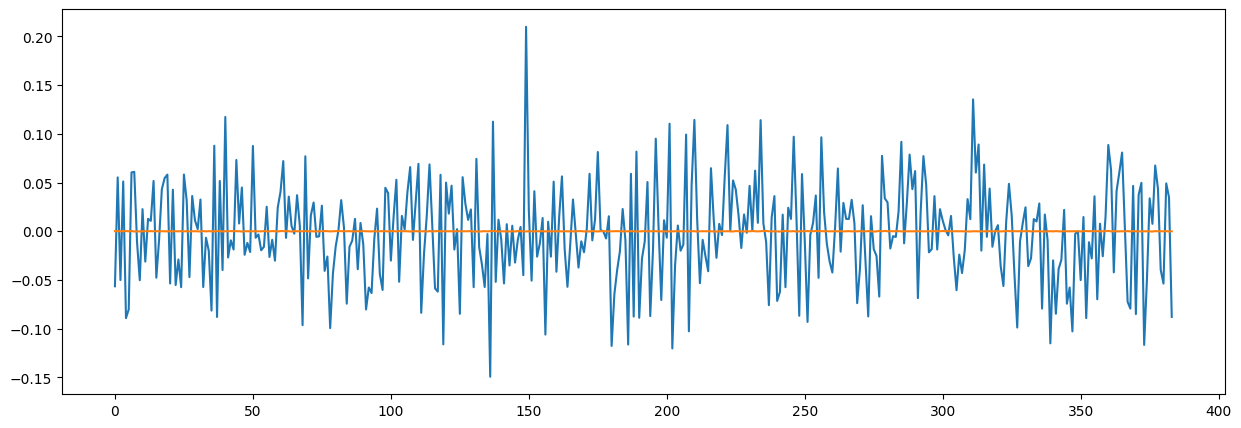

In [ ]:
k=0
from matplotlib import pyplot as plt
print(cosine_similarity(df40_comments_emb_CPU[k].reshape(1, -1) , df40_comments_emb_NPU[k].reshape(1, -1)))
df40_comments_emb_CPU[k].reshape(1, -1)[10:][:] , df40_comments_emb_NPU[k].reshape(1, -1)[10:][:]
fig,ax=plt.subplots(1,figsize=(15,5))
plt.plot(df40_comments_emb_CPU[k])
plt.plot(df40_comments_emb_CPU[k]-df40_comments_emb_NPU[k])

In [ ]:
# Supposons que vous ayez extrait l'embedding pour la même phrase :
# vec_cpu: [1, 384] généré par SentenceTransformer classique
# vec_npu: [1, 384] généré par votre CompiledModel sur NPU

# On aplatit pour le calcul
def cosinons_cpu_npu(k):
    v_cpu = df40_comments_emb_CPU[k].reshape(1, -1)
    v_npu = df40_comments_emb_NPU[k].reshape(1, -1)

    # Calcul
    score = cosine_similarity(v_cpu, v_npu)[0][0]

    print(f"📊 Score de Fidélité NPU vs CPU : {score:.6f}")

    if score > 0.999:
        print("✅ Parité quasi-parfaite. L'optimisation OpenVINO est transparente.")
    elif score > 0.99:
        print("⚠️ Légère dérive due au FP16, mais sans impact sur la classification.")
    else:
        print("❌ Écart significatif. Vérifiez le pooling ou la précision de l'export.")

cosinons_cpu_npu(3000)

📊 Score de Fidélité NPU vs CPU : 0.999996
✅ Parité quasi-parfaite. L'optimisation OpenVINO est transparente.


# Travail sur le modèle complet est inutile car il est en fp32, la conversion fp16 est du
# 
 optimum-cli export openvino \
    --model sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 \
    --task feature-extraction \
    --weight-format fp32 \
    data/PM-MiniLM-L12-v2-fp32

## FP32 compatible NPU ?

**Non** — et c'est une double contrainte :

| | FP32 | FP16 |
|---|---|---|
| NPU Intel | ❌ non supporté | ✅ supporté |
| Taille | ~470 MB | ~235 MB |
| Précision | maximale | légère perte négligeable |
| Vitesse NPU | — | ✅ optimisé |

Le NPU Intel **n'accepte que FP16** — c'est une limitation matérielle, pas logicielle. Le NPU est conçu pour faire du calcul FP16 efficacement, le FP32 n'est pas dans son jeu d'instructions.

---

## Conclusion
```
Modèle complet   → inutile, problématique, abandonné
Modèle fp16      → ✅ la bonne solution pour GPU et NPU
FP32 réexporté   → inutile pour votre cas    